# Agent 365 Session Sampling: Sampled vs. Census

This notebook evaluates `trace_sampling_alt` end to end on the labeled synthetic Agent 365 OTLP artifact:

- **Input:** 300 labeled sessions represented by 2,496 spans.
- **Census:** evaluate every normalized session once.
- **Probability arm:** per-agent Cochran/FPC sampling with no diversity reserve.
- **Diversity arm:** the same total per-agent budget, split into probability core plus a 20% MinHash farthest-first reserve.
- **Metric:** binary Task Completion.

The census judge run is reused for both sampling arms. This isolates sampling error and avoids paying twice for identical LLM judgments.

## Provider routing

Maven source confirms that friendly model `gpt-5` maps to CAPI model `gpt-5-2025-08-07`, uses JSON chat completions, `max_completion_tokens`, and no fixed temperature. Direct CAPI access is internal to Maven's .NET service and requires first-party authentication and island routing. This notebook probes a hosted Maven EvalHarness when configured; otherwise its opt-in live path uses the existing Azure OpenAI/Foundry `gpt-5` deployment with the same parameter behavior.

No credentials, evidence packets, prompts, or judge reasoning are written to experiment artifacts.

In [1]:
from __future__ import annotations

import asyncio
import json
import os
from pathlib import Path
import sys
from urllib.parse import urlparse

import matplotlib.pyplot as plt
import pandas as pd

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "trace_sampling_alt").exists():
    raise RuntimeError("Run this notebook from the singlenotebooks repository root")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from trace_sampling_alt import (
    AzureOpenAIJudge,
    AzureOpenAIJudgeSettings,
    DatasetGroundTruthJudge,
    MavenCapiSettings,
    resume_policies_vs_census,
    RunnerConfig,
    SamplePolicy,
    load_synthetic_a365_otel,
    probe_maven_availability,
    run_policies_vs_census,
    save_multi_policy_result,
)

DATA_PATH = Path(
    os.environ.get(
        "ALT_SAMPLING_DATA_PATH",
        r"C:\Users\stangoodwin\eval-model-comparison\data\eval-harness\synthetic_observability.a365-otel.json",
    )
)
META_PATH = DATA_PATH.with_name("synthetic_observability.a365-otel.meta.json")
OUTPUT_DIR = REPO_ROOT / "outputs_alt_sampling"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Live evaluation is intentionally opt-in because a 300-session census is a paid run.
RUN_LIVE_GPT5 = os.environ.get("RUN_LIVE_GPT5", "0") == "1"
LIVE_ENV_PATH = Path(
    os.environ.get(
        "ALT_SAMPLING_LIVE_ENV",
        r"C:\Users\stangoodwin\eval-model-comparison\.env",
    )
)

print({
    "data_exists": DATA_PATH.exists(),
    "metadata_exists": META_PATH.exists(),
    "output_dir": str(OUTPUT_DIR),
    "live_gpt5_enabled": RUN_LIVE_GPT5,
})

{'data_exists': True, 'metadata_exists': True, 'output_dir': 'C:\\Users\\stangoodwin\\singlenotebooks\\outputs_alt_sampling', 'live_gpt5_enabled': False}


## 1. Load and Audit the Synthetic OTLP Dataset

The loader extracts ground-truth Task Completion labels from root `invoke_agent` span attributes, normalizes all OTLP spans into Agent 365 session units, and joins labels by tenant, agent, and conversation identity.

The source artifact has no explicit session IDs, so each conversation is sessionized through the 30-minute inactivity fallback. This is appropriate for this synthetic fixture but differs from production Agent 365 data, where `sessionId` is expected to be authoritative.

In [2]:
dataset = load_synthetic_a365_otel(DATA_PATH)
source_meta = json.loads(META_PATH.read_text(encoding="utf-8"))

unit_rows = [
    {
        "tenant_id": unit.tenant_id,
        "agent_id": unit.agent_id,
        "unit_id": unit.unit_id,
        "conversation_count": len(unit.conversation_ids),
        "turn_count": len(unit.turns),
        "tool_call_count": len(unit.tool_calls),
        "started_at": unit.started_at,
        "ended_at": unit.ended_at,
        "expected_pass": dataset.labels_by_unit[unit.unit_id or ""],
    }
    for unit in dataset.normalization.units
]
units_df = pd.DataFrame(unit_rows)

metadata_case_count = int(source_meta["caseCount"])
normalized_sessions = len(units_df)
label_count = len(dataset.labels_by_unit)
assert metadata_case_count == normalized_sessions, f"caseCount mismatch: metadata={metadata_case_count}, normalized={normalized_sessions}"
assert metadata_case_count == label_count, f"caseCount mismatch: metadata={metadata_case_count}, labels={label_count}"
assert metadata_case_count == 300, f"Expected 300 cases, found {metadata_case_count}"

metadata_summary = {
    "metadata_case_count": metadata_case_count,
    "metadata_span_count": source_meta["spanCount"],
    "normalized_sessions": normalized_sessions,
    "label_count": label_count,
    "agents": units_df[["tenant_id", "agent_id"]].drop_duplicates().shape[0],
    "passes": int(units_df["expected_pass"].sum()),
    "failures": int((~units_df["expected_pass"]).sum()),
    "start": units_df["started_at"].min(),
    "end": units_df["ended_at"].max(),
    "ingest_issues": len(dataset.normalization.issues),
}
metadata_summary

{'metadata_case_count': 300,
 'metadata_span_count': 2496,
 'normalized_sessions': 300,
 'label_count': 300,
 'agents': 100,
 'passes': 188,
 'failures': 112,
 'start': Timestamp('2026-05-04 14:20:00+0000', tz='UTC'),
 'end': Timestamp('2026-07-21 08:13:45+0000', tz='UTC'),
 'ingest_issues': 0}

In [3]:
agent_counts = (
    units_df.groupby(["tenant_id", "agent_id"], as_index=False)
    .agg(sessions=("unit_id", "count"), census_pass_rate=("expected_pass", "mean"))
    .sort_values(["sessions", "agent_id"], ascending=[False, True])
)
print(agent_counts["sessions"].describe().to_string())
agent_counts.head(15)

count    100.000000
mean       3.000000
std        7.275252
min        1.000000
25%        1.000000
50%        1.000000
75%        1.250000
max       51.000000


,tenant_id,agent_id,sessions,census_pass_rate
71,badf1f56-284d-4dc5-ac59-0dd53900e743,code-review-copilot,51,0.745098
23,3f2a9c14-7b6e-4d21-9a8f-1c5e0b7d4e62,notebook-insights-agent,42,0.595238
59,7c1e5a90-2d4b-4f83-b6a1-9e0c3f5a8d21,theorem-prover-assistant,35,0.714286
1,3f2a9c14-7b6e-4d21-9a8f-1c5e0b7d4e62,benefits-enrollment-agent,7,0.285714
67,badf1f56-284d-4dc5-ac59-0dd53900e743,cad-tolerance-advisor,7,0.571429
2,3f2a9c14-7b6e-4d21-9a8f-1c5e0b7d4e62,campaign-copy-agent,6,0.833333
41,7c1e5a90-2d4b-4f83-b6a1-9e0c3f5a8d21,deal-desk-assistant,6,0.500000
54,7c1e5a90-2d4b-4f83-b6a1-9e0c3f5a8d21,press-release-drafter,6,0.500000
99,badf1f56-284d-4dc5-ac59-0dd53900e743,vendor-sourcing-agent,6,0.666667
70,badf1f56-284d-4dc5-ac59-0dd53900e743,clinical-triage-assistant,5,0.800000


## 2. Sampling-Only Experiment Against Ground Truth

This arm uses the dataset label as the judge outcome. It measures only sampling error, not LLM judge error.

Two policies reuse one 300-session census evaluation:

1. **Probability only:** all selected budget goes to the estimand-eligible stratified core.
2. **20% diversity reserve:** the same total budget is split between probability core and MinHash diversity.

Because the product rule plans independently per agent and this fixture contains 100 agents, most small-agent populations become censuses. The expected savings are therefore modest; that is a property of this dataset and estimand, not a harness failure.

In [4]:
policies = {
    "probability_only": SamplePolicy(margin=0.10, confidence=0.95, diversity_enabled=False, seed=13),
    "diversity_20pct": SamplePolicy(margin=0.10, confidence=0.95, diversity_enabled=True, diversity_fraction=0.20, seed=13),
}

sampling_result = await run_policies_vs_census(
    dataset=dataset,
    judge=DatasetGroundTruthJudge(dataset.labels_by_unit),
    policies=policies,
    runner_config=RunnerConfig(max_concurrency=32, timeout_seconds=30, max_attempts=1, base_backoff_seconds=0),
    max_evidence_bytes=32_768,
)

ground_truth_output = OUTPUT_DIR / "ground_truth_sampled_vs_census.json"
save_multi_policy_result(ground_truth_output, sampling_result)
print(f"Saved sanitized result: {ground_truth_output}")

Saved sanitized result: C:\Users\stangoodwin\singlenotebooks\outputs_alt_sampling\ground_truth_sampled_vs_census.json


In [5]:
summary_rows = []
for policy_name, arm in sampling_result.by_policy.items():
    comparison = arm.comparison
    summary_rows.append({
        "policy": policy_name,
        "population": comparison["population_total"],
        "evaluated_total": comparison["sampled_evaluated"],
        "core_n": comparison["sampled_core_evaluated"],
        "diversity_n": comparison["sampled_diversity_evaluated"],
        "census_pass_rate": comparison["census_pass_rate"],
        "sampled_core_pass_rate": comparison["sampled_core_pass_rate"],
        "signed_error_pp": 100 * comparison["signed_error"],
        "absolute_error_pp": 100 * comparison["absolute_error"],
        "ci_lower": comparison["core_ci_lower"],
        "ci_upper": comparison["core_ci_upper"],
        "census_in_interval": comparison["census_truth_in_interval"],
        "counterfactual_calls_saved": comparison["calls_saved"],
        "counterfactual_fraction_saved": comparison["fraction_saved"],
    })
summary_df = pd.DataFrame(summary_rows).sort_values("policy")
summary_df

,policy,population,evaluated_total,core_n,diversity_n,census_pass_rate,sampled_core_pass_rate,signed_error_pp,absolute_error_pp,ci_lower,ci_upper,census_in_interval,counterfactual_calls_saved,counterfactual_fraction_saved
1,diversity_20pct,300,262,244,18,0.626667,0.621574,-0.509259,0.509259,0.590403,0.652745,True,38,0.126667
0,probability_only,300,262,262,0,0.626667,0.645718,1.905128,1.905128,0.623673,0.667763,True,38,0.126667


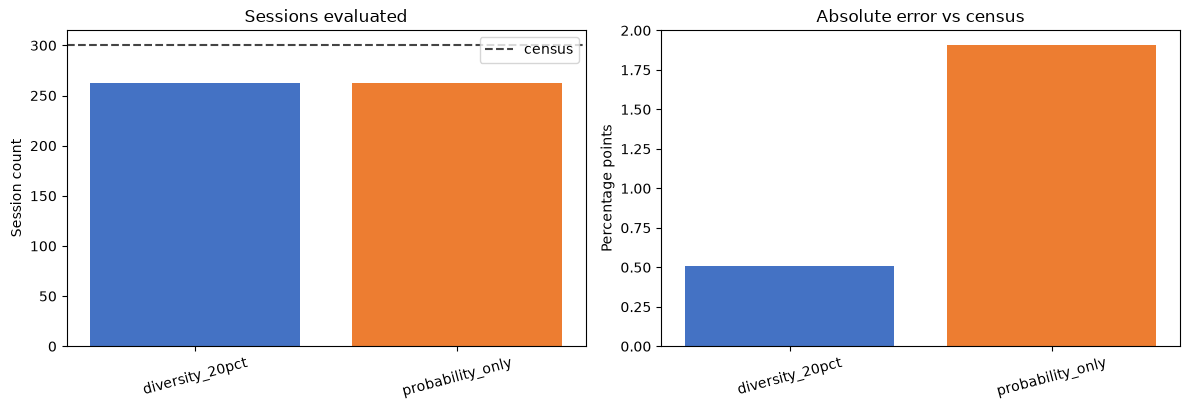

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
plot_df = summary_df.set_index("policy")
axes[0].bar(plot_df.index, plot_df["evaluated_total"], color=["#4472C4", "#ED7D31"])
axes[0].axhline(metadata_summary["normalized_sessions"], color="#444444", linestyle="--", label="census")
axes[0].set_title("Sessions evaluated")
axes[0].set_ylabel("Session count")
axes[0].tick_params(axis="x", rotation=15)
axes[0].legend()
axes[1].bar(plot_df.index, plot_df["absolute_error_pp"], color=["#4472C4", "#ED7D31"])
axes[1].set_title("Absolute error vs census")
axes[1].set_ylabel("Percentage points")
axes[1].tick_params(axis="x", rotation=15)
fig.tight_layout()
plt.show()

## 3. CAPI and GPT-5 Availability

Maven source confirms that `gpt-5` maps to CAPI model `gpt-5-2025-08-07`, uses `max_completion_tokens`, JSON output, and no fixed temperature. Direct Python-to-CAPI is not available; a hosted Maven EvalHarness must expose `GET .../eval-harness/models/check?model=gpt-5`.

When Maven is unavailable, the opt-in live path uses the configured Foundry `gpt-5` deployment with the same parameter behavior. Set `RUN_LIVE_GPT5=1` before starting the kernel. Successful prior results are resumed rather than called again.

In [7]:
maven_base = os.environ.get("MAVEN_EVAL_HARNESS_BASE_URL", "").strip()
maven_tenant = os.environ.get("MAVEN_TENANT_ID", "").strip()
if maven_base and maven_tenant:
    maven_status = probe_maven_availability(MavenCapiSettings(base_url=maven_base, tenant_id=maven_tenant, bearer_token=os.environ.get("MAVEN_BEARER_TOKEN"), model="gpt-5"))
    print({"endpoint_reachable": maven_status.endpoint_reachable, "model_available": maven_status.model_available, "status_code": maven_status.status_code})
else:
    print("Maven CAPI probe skipped: hosted EvalHarness URL and tenant were not configured.")

Maven CAPI probe skipped: hosted EvalHarness URL and tenant were not configured.


In [8]:
def _read_env_file(path: Path) -> dict[str, str]:
    values = {}
    if not path.exists():
        return values
    for raw_line in path.read_text(encoding="utf-8").splitlines():
        line = raw_line.strip()
        if line and not line.startswith("#") and "=" in line:
            key, value = line.split("=", 1)
            values[key.strip()] = value.strip().strip(chr(34)).strip(chr(39))
    return values

live_env = _read_env_file(LIVE_ENV_PATH)
live_endpoint = os.environ.get("AZURE_OPENAI_ENDPOINT") or live_env.get("AZURE_OPENAI_ENDPOINT", "")
live_api_key = os.environ.get("AZURE_OPENAI_API_KEY") or live_env.get("AZURE_OPENAI_API_KEY", "")
live_api_version = os.environ.get("AZURE_OPENAI_API_VERSION") or live_env.get("AZURE_OPENAI_API_VERSION", "2024-12-01-preview")
live_deployments = [x.strip() for x in (os.environ.get("JUDGE_DEPLOYMENTS") or live_env.get("JUDGE_DEPLOYMENTS", "")).split(",") if x.strip()]
print({"foundry_endpoint_host": urlparse(live_endpoint).hostname if live_endpoint else None, "api_key_configured": bool(live_api_key), "api_version": live_api_version, "deployments": live_deployments})

{'foundry_endpoint_host': 'bugboss-foundry.cognitiveservices.azure.com', 'api_key_configured': True, 'api_version': '2024-12-01-preview', 'deployments': ['gpt-4.1', 'gpt-5', 'gpt-5.4']}


In [9]:
live_result = None
live_output = OUTPUT_DIR / "gpt5_sampled_vs_census.json"
if RUN_LIVE_GPT5:
    if not live_endpoint or not live_api_key or "gpt-5" not in live_deployments:
        raise RuntimeError("Foundry gpt-5 configuration is incomplete")
    live_judge = AzureOpenAIJudge(AzureOpenAIJudgeSettings(endpoint=live_endpoint, api_key=live_api_key, api_version=live_api_version, deployment="gpt-5", max_completion_tokens=12_000))
    common = dict(dataset=dataset, judge=live_judge, policies=policies, runner_config=RunnerConfig(max_concurrency=2, timeout_seconds=300, max_attempts=4, base_backoff_seconds=2), max_evidence_bytes=32_768)
    if live_output.exists():
        live_result = await resume_policies_vs_census(**common, prior_path=live_output)
    else:
        live_result = await run_policies_vs_census(**common)
    save_multi_policy_result(live_output, live_result)
    print(f"Saved sanitized live result: {live_output}")
else:
    print("Live GPT-5 census skipped. Set RUN_LIVE_GPT5=1 and restart the kernel to enable it.")

Live GPT-5 census skipped. Set RUN_LIVE_GPT5=1 and restart the kernel to enable it.


## 4. Results and Interpretation

The ground-truth arm isolates sampling error. A single seed is not a coverage study; repeat many seeds for repeated-sampling claims. The 100-agent fixture causes many small populations to become censuses, so savings are modest. Pooling all sessions would change the estimand and is not used.

The live result is valid only when the census is complete and all sampled-core agent populations have responses.

In [10]:
live_artifact = OUTPUT_DIR / "gpt5_sampled_vs_census.json"
if live_artifact.exists():
    live_payload = json.loads(live_artifact.read_text(encoding="utf-8"))
    rows = []
    for policy_name, policy_result in sorted(live_payload.get("policies", {}).items()):
        c = policy_result["comparison"]
        rows.append({
            "policy": policy_name,
            "census_complete": c.get("census_complete"),
            "comparison_valid": c.get("comparison_valid"),
            "census_responses": c.get("census_evaluated"),
            "census_failures": c.get("census_failure_count"),
            "sampled_core_n": c.get("sampled_core_evaluated"),
            "sampled_diversity_n": c.get("sampled_diversity_evaluated"),
            "judge_accuracy": c.get("judge_accuracy_census_overall"),
            "census_pass_rate": c.get("census_pass_rate"),
            "sampled_core_pass_rate": c.get("sampled_core_pass_rate"),
            "absolute_error_pp": None if c.get("absolute_error") is None else 100 * c["absolute_error"],
            "census_in_interval": c.get("census_truth_in_interval"),
        })
    display(pd.DataFrame(rows))
else:
    print("No live GPT-5 artifact is present yet.")

,policy,census_complete,comparison_valid,census_responses,census_failures,sampled_core_n,sampled_diversity_n,judge_accuracy,census_pass_rate,sampled_core_pass_rate,absolute_error_pp,census_in_interval
0,diversity_20pct,False,False,172,128,143,11,None,None,None,None,None
1,probability_only,False,False,172,128,151,0,None,None,None,None,None
